In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from properscoring import crps_ensemble
import os
import sys
import calendar

In [2]:
# Add the path to the src directory (two levels up)
sys.path.append(os.path.abspath('../../'))
from src.data_loader import DataLoader
from src.data_processor import CFSProcessor, CNBSForecaster, ForecastTransformer
from src.database_utils import CFSDatabase
from src.plotting import plot_cnbs_forecast, plot_cnbs_forecast_interactive
from src.utilities import get_first_forecast_month

In [3]:
# Directory where the repository is cloned
local_path = '/Users/ljob/Desktop/'

# Path to data directory
input_dir = local_path + 'cnbs-predictor/data/'

# Path to input CFS forecast database
cfs_database = local_path+ 'Data/cfs_forecast_archive_2011-2024.db'
cfs_table = 'cfs_forecast_data'

# Path to save CNBS forecast output to a database
cnbs_database = local_path + 'Data/cnbs_forecast_verification.db'
cnbs_table = 'cnbs_forecast'

# Path to GLSEA SST data
glsea_data = input_dir + 'glsea/oisst_sst_1981-2024.csv'

# Path to SNODAS data
snodas_data = input_dir + 'snodas/SWE.SNODAS.GL.csv'

# Path to saved scalers
model_dir = input_dir + "input/models/"
scaler_dir = input_dir + "input/scalers/"

# List of models to run
models_info = ['GP', 'RF', 'NN', 'XGB']

In [4]:
# Load CFS forecast data from the database and format it before predicting CNBS
data = CFSDatabase(cfs_database, cfs_table).load()

In [5]:
print(data.head())

      cfs_run  year  month            lake surface_type      component  \
0  2011040100  2011      4            erie         lake  precipitation   
1  2011040100  2011      4            erie         land  precipitation   
2  2011040100  2011      4         ontario         lake  precipitation   
3  2011040100  2011      4         ontario         land  precipitation   
4  2011040100  2011      4  michigan-huron         lake  precipitation   

   value [mm]  
0  151.103405  
1  154.762367  
2  104.558926  
3  116.434244  
4  142.312715  


In [6]:
X = CFSProcessor.structure_input(data)

# Double check for NaNs in the input dataset
if X.isna().any().any():
    print("NaNs were found in the input dataset. Details below:\n")

    # Show row indices with any NaNs as a data check
    print("\nRows with NaNs:")
    print(X[X.isna().any(axis=1)])

    print("\nRemoving rows with NaN values before continuing.\n")
    X = X.dropna(how='any')

In [7]:
print(X)

                     month_1  month_2  month_3  month_4  month_5  month_6  \
cfs_run                                                                     
2011-04-01 00:00:00    False    False    False     True    False    False   
2011-04-01 06:00:00    False    False    False     True    False    False   
2011-04-01 12:00:00    False    False    False     True    False    False   
2011-04-01 18:00:00    False    False    False     True    False    False   
2011-04-02 00:00:00    False    False    False     True    False    False   
...                      ...      ...      ...      ...      ...      ...   
2024-11-16 18:00:00    False    False    False    False    False    False   
2024-12-07 00:00:00    False    False    False    False    False    False   
2024-12-07 06:00:00    False    False    False    False    False    False   
2024-12-07 12:00:00    False    False    False    False    False    False   
2024-12-07 18:00:00    False    False    False    False    False    False   

In [8]:
df = X.drop(columns=[col for col in X.columns if col.startswith("month")])

In [9]:
# Path to GLSEA SST data
df_sst_k = DataLoader().glsea(input_dir + 'glsea/oisst_sst_1981-2024.csv', 'K')
df_sst = df_sst_k.reindex(X.index, method="ffill")

In [10]:
X_merged = pd.merge(df_sst, X, left_index=True, right_index=True, how='inner')

In [14]:
print(X_merged)

                     superior_sst  michigan-huron_sst  erie_sst  ontario_sst  \
cfs_run                                                                        
2011-04-01 00:00:00        273.60             274.360    274.08       275.52   
2011-04-01 06:00:00        273.60             274.360    274.08       275.52   
2011-04-01 12:00:00        273.60             274.360    274.08       275.52   
2011-04-01 18:00:00        273.60             274.360    274.08       275.52   
2011-04-02 00:00:00        273.35             274.370    274.22       275.54   
...                           ...                 ...       ...          ...   
2024-11-16 18:00:00        280.89             283.785    285.65       284.07   
2024-12-07 00:00:00        278.56             280.150    279.85       280.04   
2024-12-07 06:00:00        278.56             280.150    279.85       280.04   
2024-12-07 12:00:00        278.56             280.150    279.85       280.04   
2024-12-07 18:00:00        278.56       

In [11]:
eri_lake = 18596.39
eri_land = 81902.18
ont_lake = 15569.25
ont_land = 64465.19
mih_lake = 123626.28
mih_land = 236478.94
sup_lake = 78288.65
sup_land = 123736.05

mic_land = 118000.00
hur_land = 134100.00


snodas_data = pd.read_csv(local_path+'DoD SAFE-8WBhd9qAMBPtYPKG/Snodas/SWE.SNODAS.GL.csv',sep=',', skiprows=5)
snodas_data['date'] = pd.to_datetime(snodas_data[['year', 'month', 'day']])
snodas_data['michigan-huron_snodas'] = (snodas_data['MIC']*mic_land + snodas_data['HUR']*hur_land) / (mih_land)
snodas_data = snodas_data.rename(columns={
    'SUP': 'superior_snodas',
    'ERI': 'erie_snodas',
    'ONT': 'ontario_snodas'
})
snodas = snodas_data[[
    'date',
    'superior_snodas',
    'michigan-huron_snodas',
    'erie_snodas',
    'ontario_snodas'
]]
snodas.set_index('date', inplace=True)

aligned_snodas, aligned_X_merged = snodas.align(X_merged, join='inner', axis=0)
#snodas_shifted = CFSProcessor.shift_variables(aligned_snodas, lag=3, lead=0)
#print(snodas_shifted)

In [12]:
print(aligned_snodas)

            superior_snodas  michigan-huron_snodas   erie_snodas  \
2011-04-01     1.220020e+02           6.250837e+01  6.993540e+00   
2011-04-02     1.226820e+02           6.008892e+01  3.838240e+00   
2011-04-03     1.216890e+02           5.607686e+01  1.483410e+00   
2011-04-04     1.262070e+02           5.724212e+01  1.368400e+00   
2011-04-05     1.350030e+02           5.451844e+01  2.599490e-01   
...                     ...                    ...           ...   
2024-08-30     0.000000e+00           0.000000e+00  0.000000e+00   
2024-10-01     2.750000e-10           1.843830e-10  1.090000e-10   
2024-10-26     8.466290e-04           1.843830e-10  1.090000e-10   
2024-11-16     6.108330e-01           1.741057e-02  1.090000e-10   
2024-12-07     2.499100e+01           2.681277e+01  1.304300e+01   

            ontario_snodas  
2011-04-01    3.218580e+01  
2011-04-02    3.094100e+01  
2011-04-03    2.786880e+01  
2011-04-04    2.613950e+01  
2011-04-05    2.259230e+01  
...      

In [13]:
X_merged_2 = pd.merge(aligned_snodas, aligned_X_merged, left_index=True, right_index=True, how='inner')

In [14]:
print(X_merged_2)

            superior_snodas  michigan-huron_snodas   erie_snodas  \
2011-04-01     1.220020e+02           6.250837e+01  6.993540e+00   
2011-04-02     1.226820e+02           6.008892e+01  3.838240e+00   
2011-04-03     1.216890e+02           5.607686e+01  1.483410e+00   
2011-04-04     1.262070e+02           5.724212e+01  1.368400e+00   
2011-04-05     1.350030e+02           5.451844e+01  2.599490e-01   
...                     ...                    ...           ...   
2024-08-30     0.000000e+00           0.000000e+00  0.000000e+00   
2024-10-01     2.750000e-10           1.843830e-10  1.090000e-10   
2024-10-26     8.466290e-04           1.843830e-10  1.090000e-10   
2024-11-16     6.108330e-01           1.741057e-02  1.090000e-10   
2024-12-07     2.499100e+01           2.681277e+01  1.304300e+01   

            ontario_snodas  superior_sst  michigan-huron_sst  erie_sst  \
2011-04-01    3.218580e+01        273.60             274.360    274.08   
2011-04-02    3.094100e+01        2

In [16]:
# Initialize model forecaster
model_runner = CNBSForecaster(model_dir, scaler_dir)

# Run predictions for each model
model_predictions = []
for model_name in model_runner.models.keys():
    print(f"Predicting with {model_name}...")
    df_y = model_runner.predict(X_merged_2, model_name)
    model_predictions.append(df_y)

# Combine all predictions
df_all = pd.concat(model_predictions).reset_index()

Predicting with NN...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step
Predicting with XGB...
Predicting with RF...
Predicting with GP...


In [17]:
df_all = df_all.rename(columns={'index': 'cfs_run'})

In [18]:
# Step 1: Melt into long format
df_melted = df_all.melt(
    id_vars=['cfs_run', 'model'],
    var_name='variable',
    value_name='value'
)

# Step 2: Split into lake, variable, and month_offset
split_cols = df_melted['variable'].str.rsplit('_', n=2, expand=True)
df_melted['component'] = split_cols[0] + '_' + split_cols[1]
df_melted['month_offset'] = split_cols[2].str.replace('mo', '', regex=False).astype(int)

# Step 3: Compute forecast_month
df_melted['forecast_month'] = df_melted.apply(
    lambda row: (pd.to_datetime(row['cfs_run']) + pd.DateOffset(months=row['month_offset'])).strftime('%Y-%m'),
    axis=1
)
df_melted = df_melted.drop(columns=['month_offset'])

# Step 4: Pivot so each variable type is its own column
df_tidy = df_melted.pivot_table(
    index=['cfs_run', 'model', 'forecast_month'],
    columns='component',
    values='value'
).reset_index()
df_tidy.columns.name = None

In [19]:
df_tidy["date"] = pd.to_datetime(df_tidy["forecast_month"], format="%Y-%m")

In [20]:
transformer = ForecastTransformer(df_all)

df_pivot = transformer.pivot()

In [21]:
# Save to a CSV [mm]
df_pivot.to_csv('CNBS_forecast_ver.csv', sep='\t', index=False)

In [22]:
# Open and load observational data

l2_obs = DataLoader().l2swbm(input_dir + 'l2swbm/')
l2_obs = l2_obs.reset_index()

glcc_obs = DataLoader().glcc(input_dir + 'glcc/', 'mm')
glcc_obs = glcc_obs.reset_index()

In [23]:
# Merge on forecast_month = date
df_merged = pd.merge(
    df_tidy,
    l2_obs,
    on='date',
    how='inner'
)

df_combined = pd.merge(
    df_merged,
    glcc_obs,
    on='date',
    how='inner'
)

df_combined = df_combined.dropna()

In [24]:
from properscoring import crps_ensemble
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

def calculate_ensemble_skill(df, var_list, model, date_col='date'):
    df_model = df[df['model'] == model]

    all_obs = []
    all_pred_means = []
    all_pred_ensembles = []

    for var in var_list:
        pred_col = var
        obs_col = f"{var}_obs"

        #if pred_col not in df_model.columns or obs_col not in df_model.columns:
        #    print(f"Warning: Missing columns for '{var}', skipping.")
        #    continue

        data = df_model[[date_col, pred_col, obs_col]].dropna()

        grouped = data.groupby(date_col)

        for date, group in grouped:
            obs = group[obs_col].iloc[0]  # repeated obs per date
            preds = group[pred_col].values

            all_obs.append(obs)
            all_pred_means.append(np.mean(preds))
            all_pred_ensembles.append(preds)

    all_obs = np.array(all_obs)
    all_pred_means = np.array(all_pred_means)

    rmse = np.sqrt(mean_squared_error(all_obs, all_pred_means))
    r2 = r2_score(all_obs, all_pred_means)
    bias = np.mean(all_pred_means - all_obs)
    var_ratio = np.var(all_pred_means) / np.var(all_obs)
    nse = 1 - np.sum((all_pred_means - all_obs) ** 2) / np.sum((all_obs - np.mean(all_obs)) ** 2)
    r = np.corrcoef(all_obs, all_pred_means)[0, 1]
    alpha = np.std(all_pred_means) / np.std(all_obs)
    beta = np.mean(all_pred_means) / np.mean(all_obs)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    crps = np.mean([crps_ensemble(o, p) for o, p in zip(all_obs, all_pred_ensembles)])

    return {
        'Model': model,
        'RMSE': rmse,
        'R2': r2,
        'Bias': bias,
        'VarRatio': var_ratio,
        'NSE': nse,
        'KGE': kge,
        'CRPS': crps
    }

def plot_styled_table(df, title=None):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')  # Hide axes

    # Add title if provided
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='center',
        cellLoc='center',
        edges='closed'
    )

    # Header styling
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(12)

    # Adjust cell dimensions
    for (row, col), cell in table.get_celld().items():
        cell.set_height(0.17)
        if col == 0:
            cell.set_width(0.2)
        else:
            cell.set_width(0.15)

    table.auto_set_font_size(False)
    plt.show()

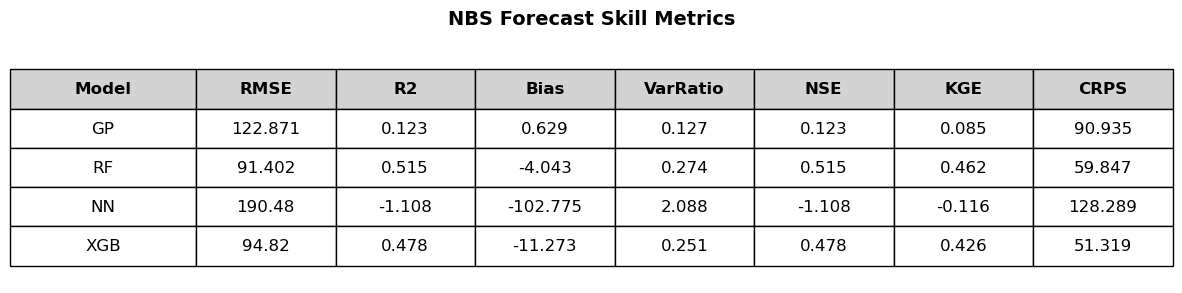

In [25]:
# variables
components = ['nbs']   # or ['precipitation', 'evaporation', 'runoff']
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

# Calculate skill for each model
models = ['GP', 'RF', 'NN', 'XGB']
results = []

for m in models:
    skill = calculate_ensemble_skill(df_combined, var_list, m, date_col='date')
    results.append(skill)

# Convert to DataFrame for pretty display
results_df = pd.DataFrame(results)

# Plot
plot_styled_table(results_df, title="NBS Forecast Skill Metrics")

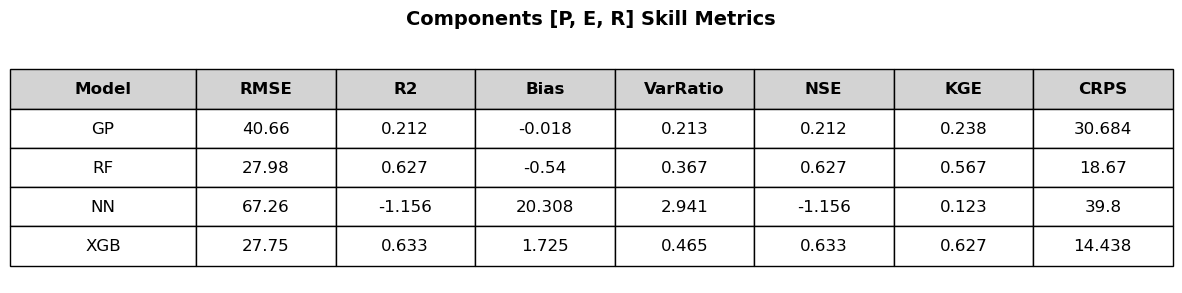

In [26]:
# variables
components = ['precipitation', 'evaporation', 'runoff']
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

# Calculate skill for each model
models = ['GP', 'RF', 'NN', 'XGB']
results = []

for m in models:
    skill = calculate_ensemble_skill(df_combined, var_list, m, date_col='date')
    results.append(skill)

# Convert to DataFrame for pretty display
results_df = pd.DataFrame(results)

# Plot
plot_styled_table(results_df, title="Components [P, E, R] Skill Metrics")

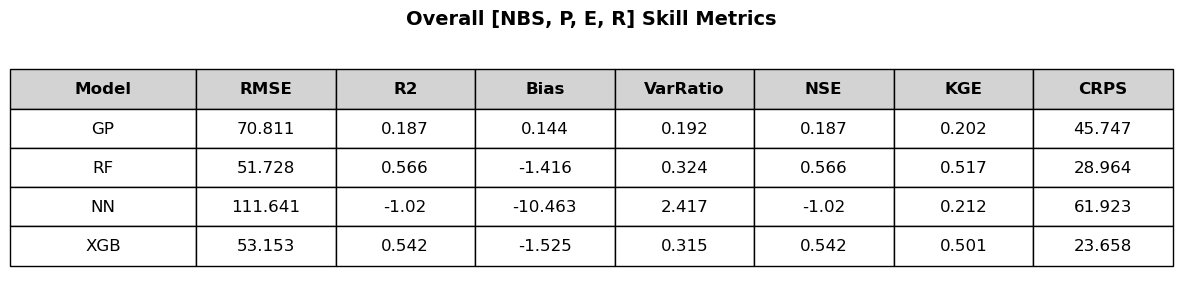

In [27]:
# variables
components = ['nbs', 'precipitation', 'evaporation', 'runoff']
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

# Calculate skill for each model
models = ['GP', 'RF', 'NN', 'XGB']
results = []

for m in models:
    skill = calculate_ensemble_skill(df_combined, var_list, m, date_col='date')
    results.append(skill)

# Convert to DataFrame for pretty display
results_df = pd.DataFrame(results)

# Plot
plot_styled_table(results_df, title="Overall [NBS, P, E, R] Skill Metrics")

In [ ]:
df_tidy['cfs_run'] = pd.to_datetime(df_tidy['cfs_run'])
df_tidy['forecast_month'] = pd.to_datetime(df_tidy['forecast_month'])

# For each forecast run, keep only the first 6 months
df_first6 = (
    df_combined.sort_values(['cfs_run', 'forecast_month'])
      .groupby(['cfs_run', 'model'])
      .head(6)  # keep first 6 rows per run/model
      .reset_index(drop=True)
)

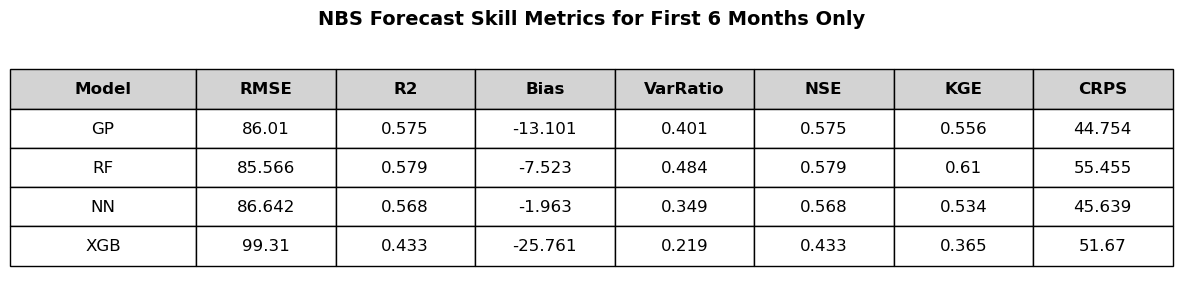

In [ ]:
# variables
components = ['nbs']   # or ['precipitation', 'evaporation', 'runoff']
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

# Calculate skill for each model
models = ['GP', 'RF', 'NN', 'XGB']
results = []

for m in models:
    skill = calculate_ensemble_skill(df_first6, var_list, m, date_col='date')
    results.append(skill)

# Convert to DataFrame for pretty display
results_df = pd.DataFrame(results)

# Plot
plot_styled_table(results_df, title="NBS Forecast Skill Metrics for First 6 Months Only")

In [ ]:
print(results_df)

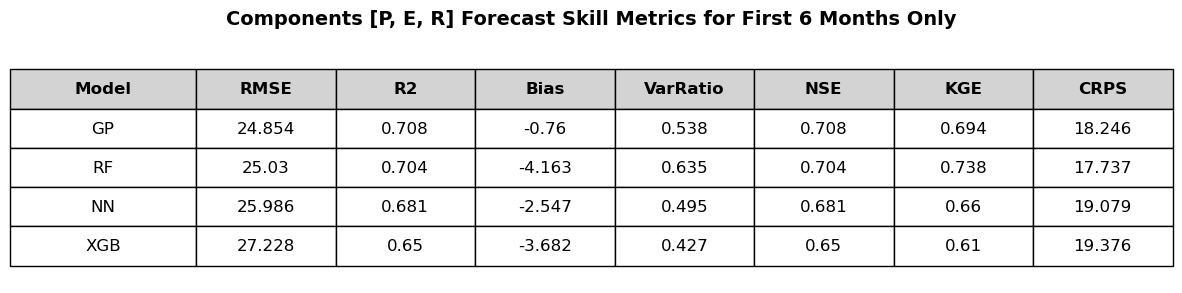

In [ ]:
# variables
components = ['precipitation', 'evaporation', 'runoff']
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

# Calculate skill for each model
models = ['GP', 'RF', 'NN', 'XGB']
results = []

for m in models:
    skill = calculate_ensemble_skill(df_first6, var_list, m, date_col='date')
    results.append(skill)

# Convert to DataFrame for pretty display
results_df = pd.DataFrame(results)

# Plot
plot_styled_table(results_df, title="Components [P, E, R] Forecast Skill Metrics for First 6 Months Only")

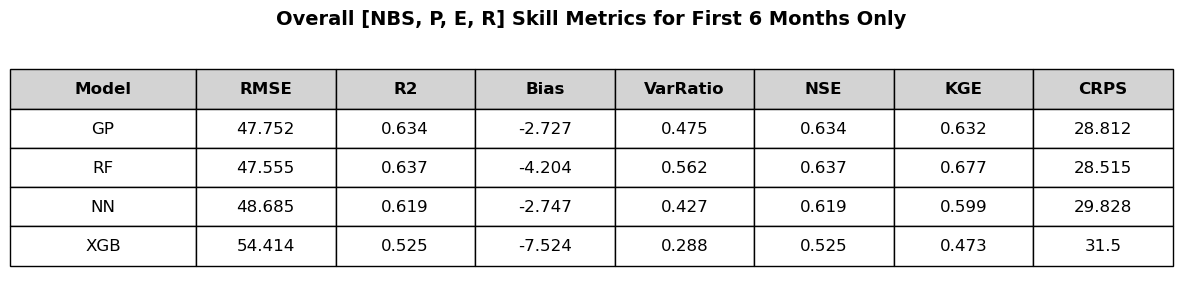

In [ ]:
# variables
components = ['nbs', 'precipitation', 'evaporation', 'runoff']
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

# Calculate skill for each model
models = ['GP', 'RF', 'NN', 'XGB']
results = []

for m in models:
    skill = calculate_ensemble_skill(df_first6, var_list, m, date_col='date')
    results.append(skill)

# Convert to DataFrame for pretty display
results_df = pd.DataFrame(results)

# Plot
plot_styled_table(results_df, title="Overall [NBS, P, E, R] Skill Metrics for First 6 Months Only")

In [29]:
df = data.copy()

df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

# 2. Filter only surface_type == lake
df = df[df["surface_type"] == "lake"]

# 3. Create "variable" column
df["variable"] = df["lake"] + "_" + df["component"]

# 4. Pivot to wide format
pivot_df = df.pivot_table(
    index=["date", "cfs_run", "forecast_month"],  # keep these as identifiers
    columns="variable",
    values="value [mm]",
    aggfunc="mean"  # in case of duplicates
).reset_index()

# Optional: flatten column names after pivot
pivot_df.columns.name = None  # remove pivot column grouping name

df_cfs_mean =(pivot_df.groupby(["date"]).mean(numeric_only=True))
df_cfs = df_cfs_mean.reset_index()

In [30]:
df_mean = df_combined.groupby(['forecast_month','model']).mean()
df_mean = df_mean.reset_index()

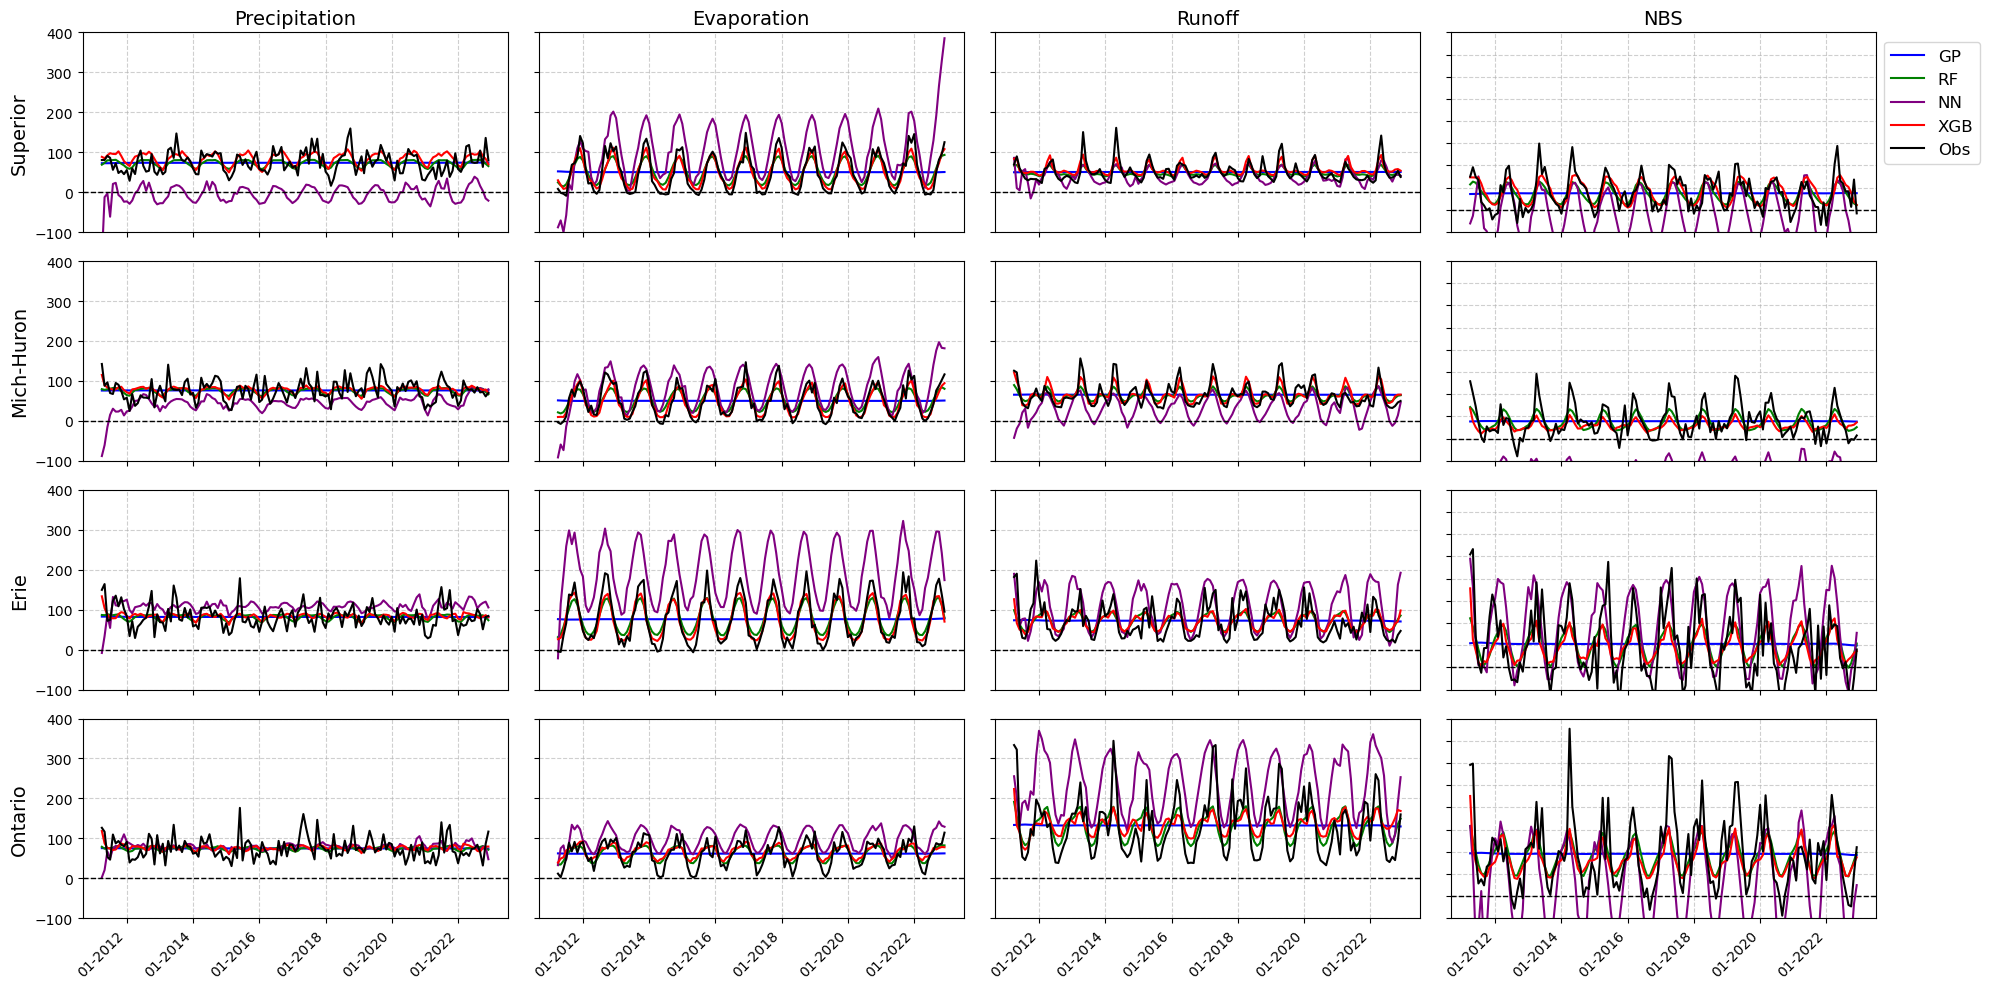

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'XGB': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['precipitation', 'evaporation', 'runoff', 'nbs']
titles = ['Precipitation', 'Evaporation', 'Runoff', 'NBS']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.reshape(4, 4)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        for model_name in models_info:
            model_df = df_mean[df_mean['model'] == model_name].copy()
            
            # Plot model prediction
            ax.plot(model_df['date'], model_df[column],
                    color=model_colors[model_name], label=model_name)

        # Plot observations
        ax.plot(model_df['date'], model_df[obs_column],
                color='black', linewidth=1.5, label='Obs')

        # Only plot CFS for precipitation + evaporation
        #if comp in ['precipitation', 'evaporation']:
        #    ax.plot(df_cfs['date'], df_cfs[column],
        #            color='orange', linewidth=1.5, label='CFS')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-100, 400)

# Add legend once
axs[0, 3].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2014-01-01')
end_date = pd.to_datetime('2015-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.savefig('CNBS_forecasts.png', dpi=300)
plt.show()


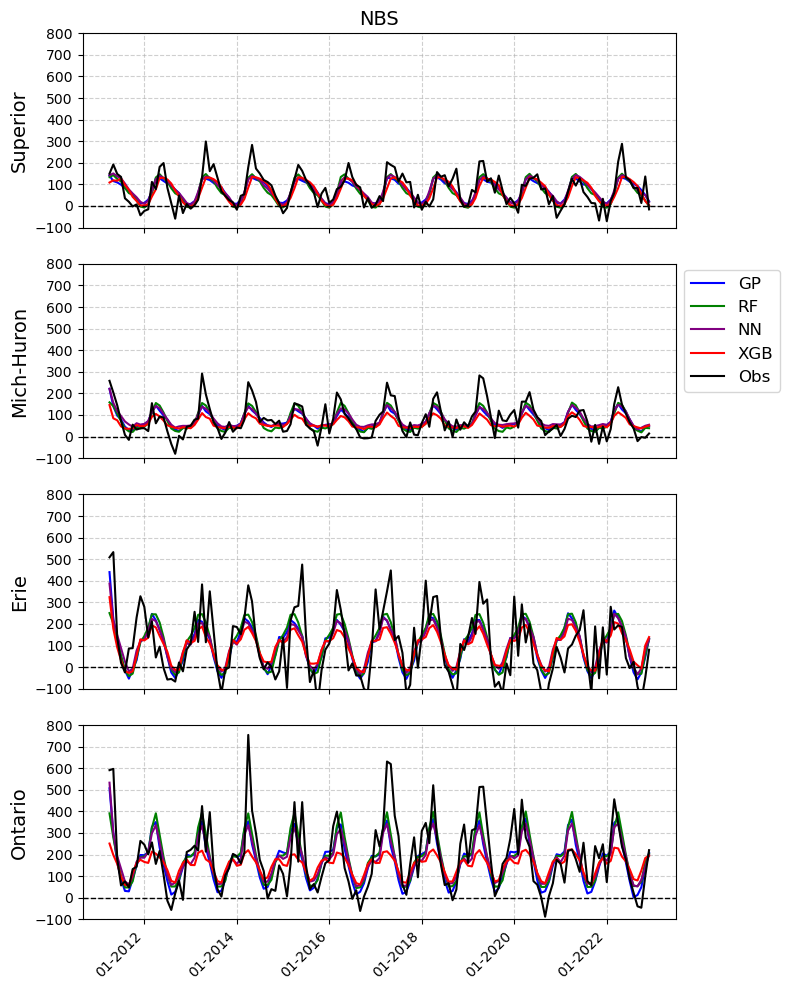

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'XGB': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['nbs']
titles = ['NBS']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 1, figsize=(8, 10))
axs = axs.reshape(4, 1)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        for model_name in models_info:
            model_df = df_mean[df_mean['model'] == model_name].copy()
            
            # Plot model prediction
            ax.plot(model_df['date'], model_df[column],
                    color=model_colors[model_name], label=model_name)

        # Plot observations
        ax.plot(model_df['date'], model_df[obs_column],
                color='black', linewidth=1.5, label='Obs')

        # Only plot CFS for precipitation + evaporation
        #if comp in ['precipitation', 'evaporation']:
        #    ax.plot(df_cfs['date'], df_cfs[column],
        #            color='orange', linewidth=1.5, label='CFS')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-100, 800)

# Add legend once
axs[1, 0].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2014-01-01')
end_date = pd.to_datetime('2015-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.savefig('NBS_forecasts.png', dpi=300)
plt.show()

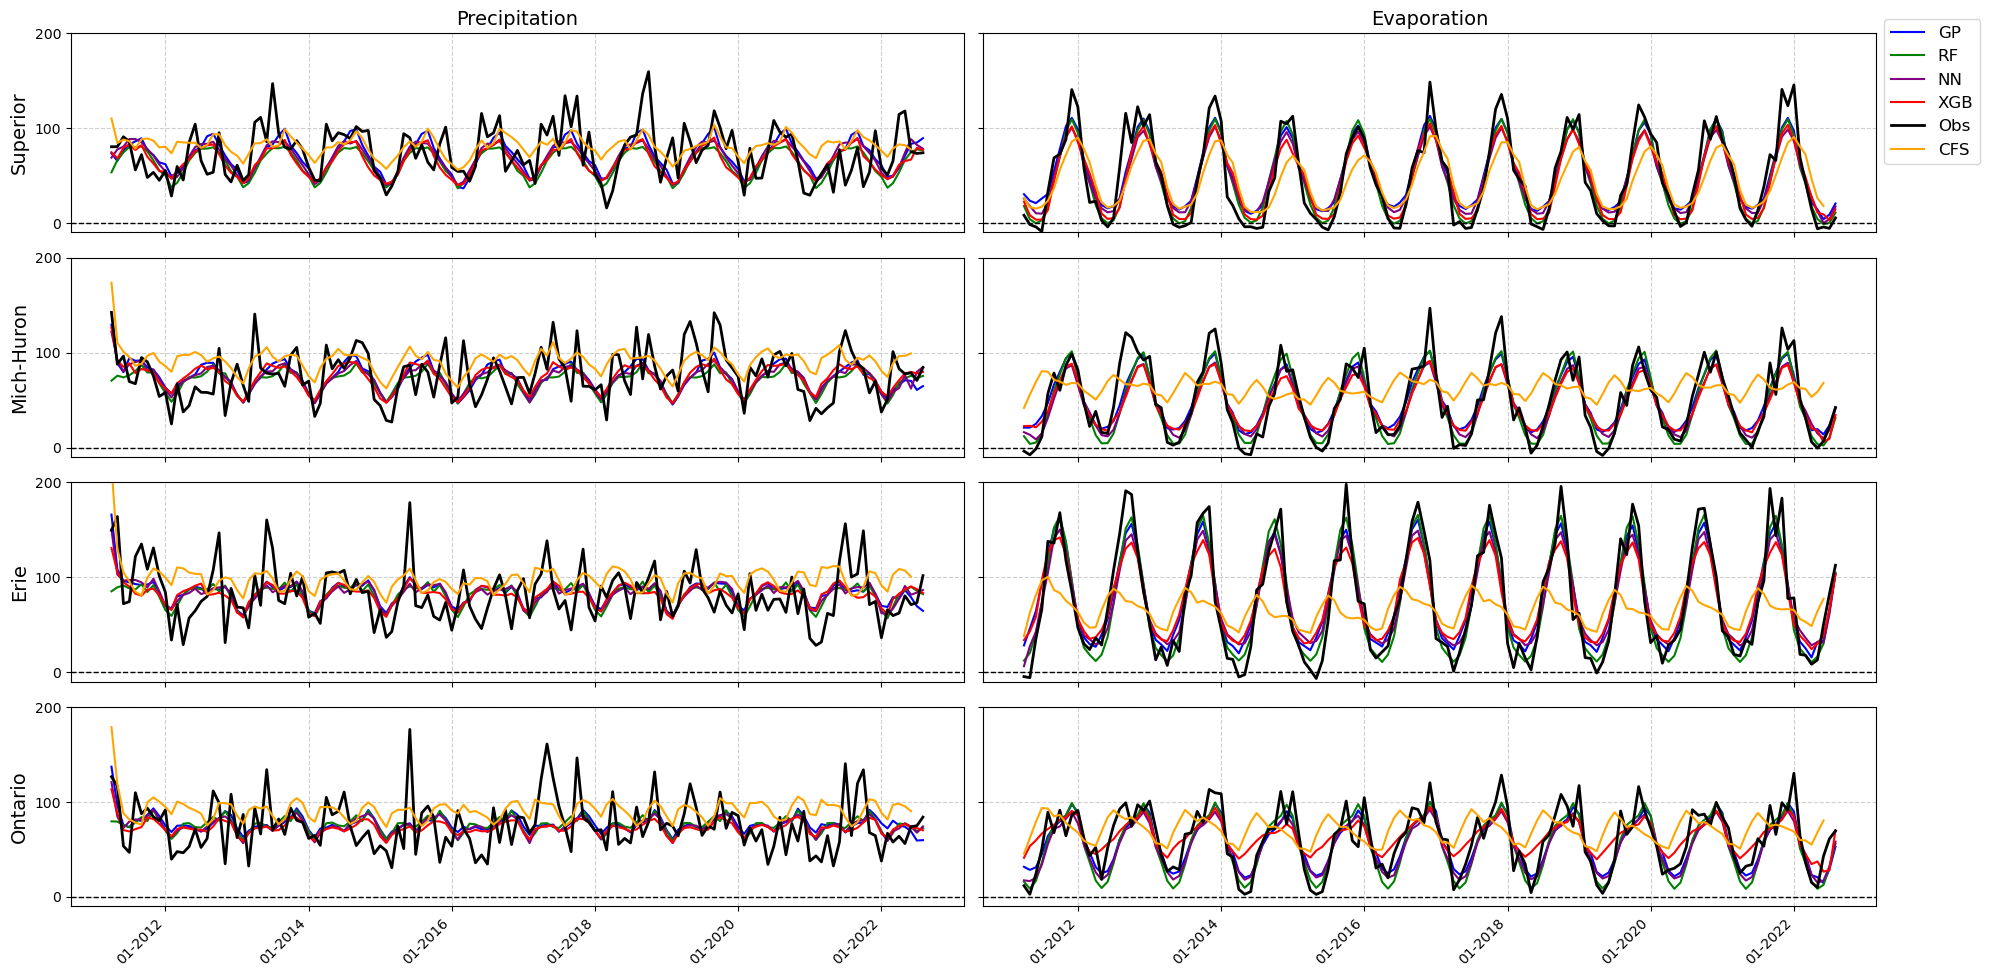

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'XGB': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['precipitation', 'evaporation']
titles = ['Precipitation', 'Evaporation']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 2, figsize=(20, 10))
axs = axs.reshape(4, 2)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        for model_name in models_info:
            model_df = df_combined[df_combined['model'] == model_name].copy()
            
            # Plot model prediction
            ax.plot(model_df['date'], model_df[column],
                    color=model_colors[model_name], linewidth=1.5, label=model_name)

        # Plot observations
        ax.plot(model_df['date'], model_df[obs_column],
                color='black', linewidth=2, label='Obs')

        # Only plot CFS for precipitation + evaporation
        if comp in ['precipitation', 'evaporation']:
            ax.plot(df_cfs['date'], df_cfs[column],
                    color='orange', linewidth=1.5, label='CFS')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-10, 200)

# Add legend once
axs[0, 1].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2021-01-01')
end_date = pd.to_datetime('2022-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.savefig('CNBS_forecasts.png', dpi=300)
plt.show()

In [ ]:
X2 = X.reset_index()
X2 = X2.groupby(['year_month']).median(numeric_only=True).reset_index()

X2_merged = pd.merge(X2, l2_obs, on=('year_month'), how='left')
X2_merged = X2_merged.dropna()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from properscoring import crps_ensemble

components = ['precipitation', 'evaporation']

# Build mapping from lake variables to corresponding observed variables
lake_to_obs = {}
for comp in components:
    lake_vars = [col for col in X2_merged.columns if col.endswith(f'_lake_{comp}')]
    for lake_col in lake_vars:
        lake_prefix = lake_col.replace(f'_lake_{comp}', '')
        obs_col = f'{lake_prefix}_{comp}_obs'
        if obs_col in X2_merged.columns:
            lake_to_obs[lake_col] = obs_col
        else:
            print(f'Observed column not found for: {lake_col}')

# Skill metric computation
def compute_skill_metrics(pred, obs):
    mask = (~pred.isna()) & (~obs.isna())
    y_pred = pred[mask].values.reshape(-1, 1)
    y_true = obs[mask].values.reshape(-1, 1)

    scaler = StandardScaler()
    y_true_std = scaler.fit_transform(y_true)
    y_pred_std = scaler.transform(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true_std, y_pred_std))
    r2 = r2_score(y_true_std, y_pred_std)
    bias = np.mean(y_pred_std - y_true_std)
    variance = np.var(y_pred_std)
    crps = np.mean(crps_ensemble(y_true_std.flatten(), y_pred_std.flatten()[:, None]))

    return {
        'rmse': round(rmse, 3),
        'r2': round(r2, 3),
        'bias': round(bias, 3),
        'variance': round(variance, 3),
        'crps': round(crps, 3)
    }

# Loop through variable pairs and compute skill
results = []
for model_col, obs_col in lake_to_obs.items():
    skill = compute_skill_metrics(X2_merged[model_col], X2_merged[obs_col])
    skill['variable'] = model_col
    results.append(skill)

# Build and display skill DataFrame
skill_df = pd.DataFrame(results)
print(skill_df)


    rmse     r2   bias  variance   crps                           variable
0  1.156 -0.336 -0.703     0.061  0.902        superior_lake_precipitation
1  1.259 -0.585 -0.778     0.050  0.979            erie_lake_precipitation
2  1.673 -1.797 -1.342     0.017  1.368         ontario_lake_precipitation
3  1.320 -0.743 -0.934     0.060  1.060  michigan-huron_lake_precipitation
4  0.823  0.323 -0.372     0.125  0.650          superior_lake_evaporation
5  1.118 -0.249 -0.594     0.026  0.820              erie_lake_evaporation
6  1.448 -1.096 -0.997     0.052  1.194           ontario_lake_evaporation
7  1.115 -0.243 -0.349     0.029  0.929    michigan-huron_lake_evaporation


In [ ]:
# Collect all model and observed values into single arrays
all_preds = []
all_obs = []

for model_col, obs_col in lake_to_obs.items():
    pred = X2_merged[model_col]
    obs = X2_merged[obs_col]
    mask = (~pred.isna()) & (~obs.isna())
    all_preds.append(pred[mask])
    all_obs.append(obs[mask])

# Concatenate into single Series
all_preds_combined = pd.concat(all_preds).reset_index(drop=True)
all_obs_combined = pd.concat(all_obs).reset_index(drop=True)

# Compute overall skill metrics
overall_skill = compute_skill_metrics(all_preds_combined, all_obs_combined)

print("Overall Skill Metrics for CFS forecast Precip and Evap:")
for k, v in overall_skill.items():
    print(f"{k}: {v}")


Overall Skill Metrics for CFS forecast Precip and Evap:
rmse: 1.125
r2: -0.267
bias: -0.642
variance: 0.115
crps: 0.867


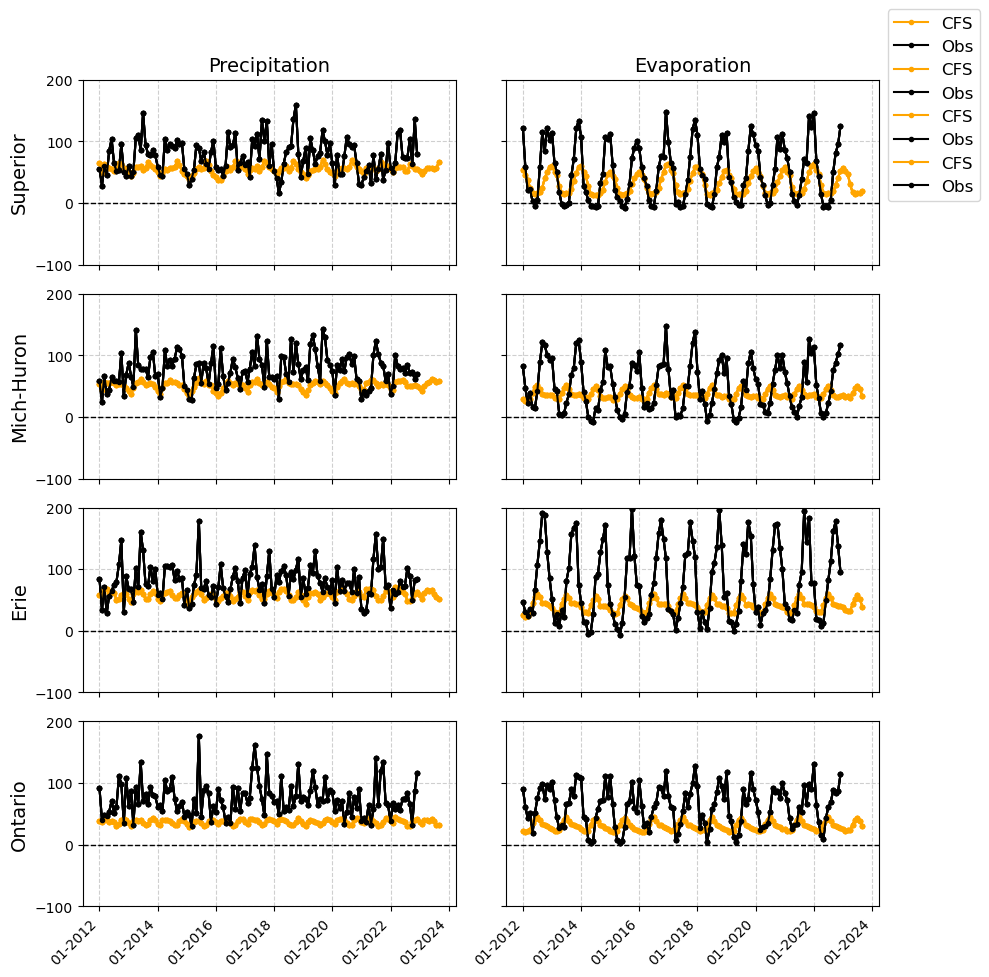

In [ ]:
# Compare precipitation and evaporation directly from CFS, model output and observations

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'LR': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['precipitation', 'evaporation']
titles = ['Precipitation', 'Evaporation',]
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 2, figsize=(10, 10))
axs = axs.reshape(4, 2)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'
        cfs_column = f'{lake}_lake_{comp}'

        for model_info in models_info:
            model_name = model_info['model']
            model_df = df_combined[df_combined['model'] == model_name].copy()
            model_df['date'] = pd.to_datetime(model_df['year_month'])
            X2['date'] = pd.to_datetime(X2['year_month'])

            # Plot model prediction
            #ax.plot(model_df['date'], model_df[column], marker='o', markersize=3,
            #        color=model_colors[model_name], label=model_name)
            ax.plot(X2['date'], X2[cfs_column], marker='o', markersize=3, color='orange', label='CFS')
            # Plot observations
            ax.plot(model_df['date'], model_df[obs_column], marker='o', markersize=3,
                    color='black', linewidth=1.5, label='Obs')

        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-100, 200)

# Add legend once
axs[0, 1].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2014-01-01')
end_date = pd.to_datetime('2015-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.show()

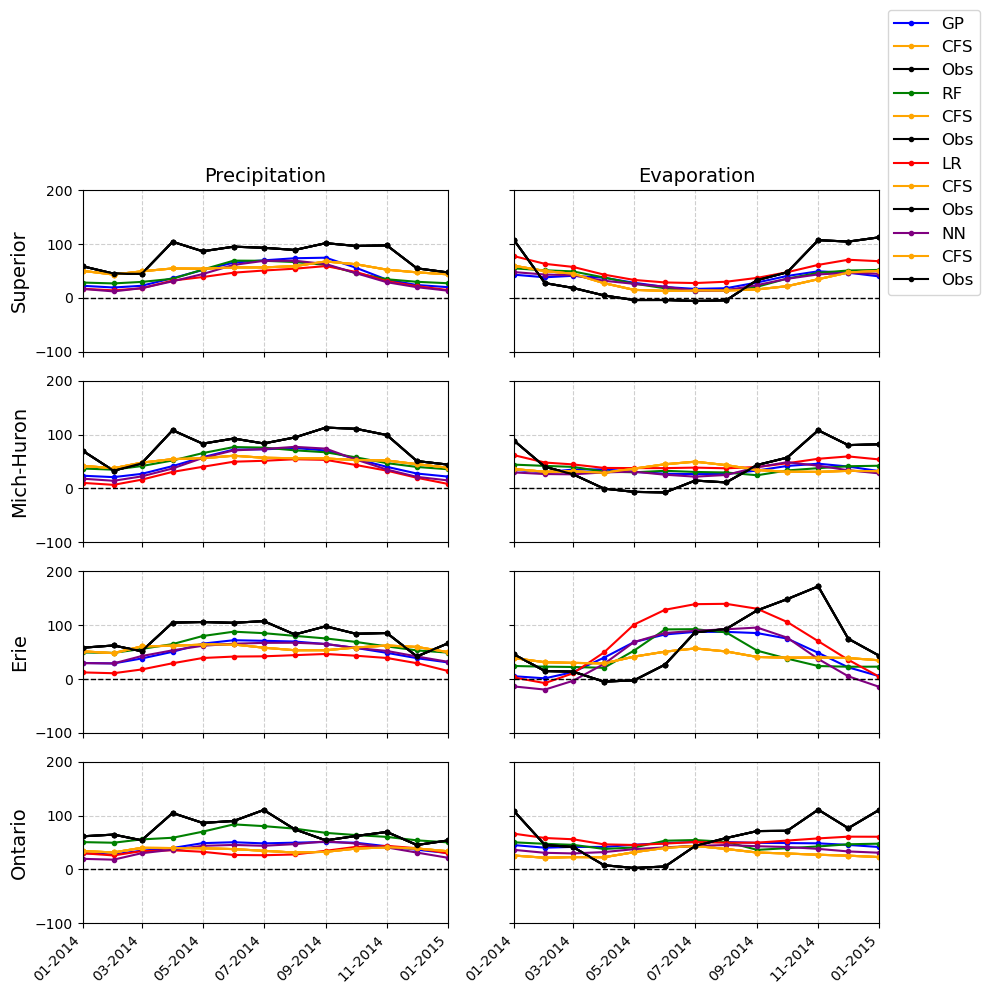

In [ ]:
# Compare precipitation and evaporation directly from CFS, model output and observations

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'LR': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['precipitation', 'evaporation']
titles = ['Precipitation', 'Evaporation',]
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 2, figsize=(10, 10))
axs = axs.reshape(4, 2)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'
        cfs_column = f'{lake}_lake_{comp}'

        for model_info in models_info:
            model_name = model_info['model']
            model_df = df_combined[df_combined['model'] == model_name].copy()
            model_df['date'] = pd.to_datetime(model_df['year_month'])
            X2['date'] = pd.to_datetime(X2['year_month'])

            # Plot model prediction
            ax.plot(model_df['date'], model_df[column], marker='o', markersize=3,
                    color=model_colors[model_name], label=model_name)
            ax.plot(X2['date'], X2[cfs_column], marker='o', markersize=3, color='orange', label='CFS')
            # Plot observations
            ax.plot(model_df['date'], model_df[obs_column], marker='o', markersize=3,
                    color='black', linewidth=1.5, label='Obs')

        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-100, 200)

# Add legend once
axs[0, 1].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2014-01-01')
end_date = pd.to_datetime('2015-01-01')

for ax_row in axs:
    for ax in ax_row:
        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.show()